Step 1: Install the libraries

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Step 2: Import the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    confusion_matrix,
    classification_report
)

from scipy.cluster.hierarchy import dendrogram, linkage

Step 3: Load and inspect the dataset

In [3]:
iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = iris.target

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
print("Dataset shape:", X.shape)
print("\nMissing values:")
print(X.isnull().sum())

print("\nDataset description:")
print(X.describe())

Dataset shape: (150, 4)

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Dataset description:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


Step 4: Visualize the raw data

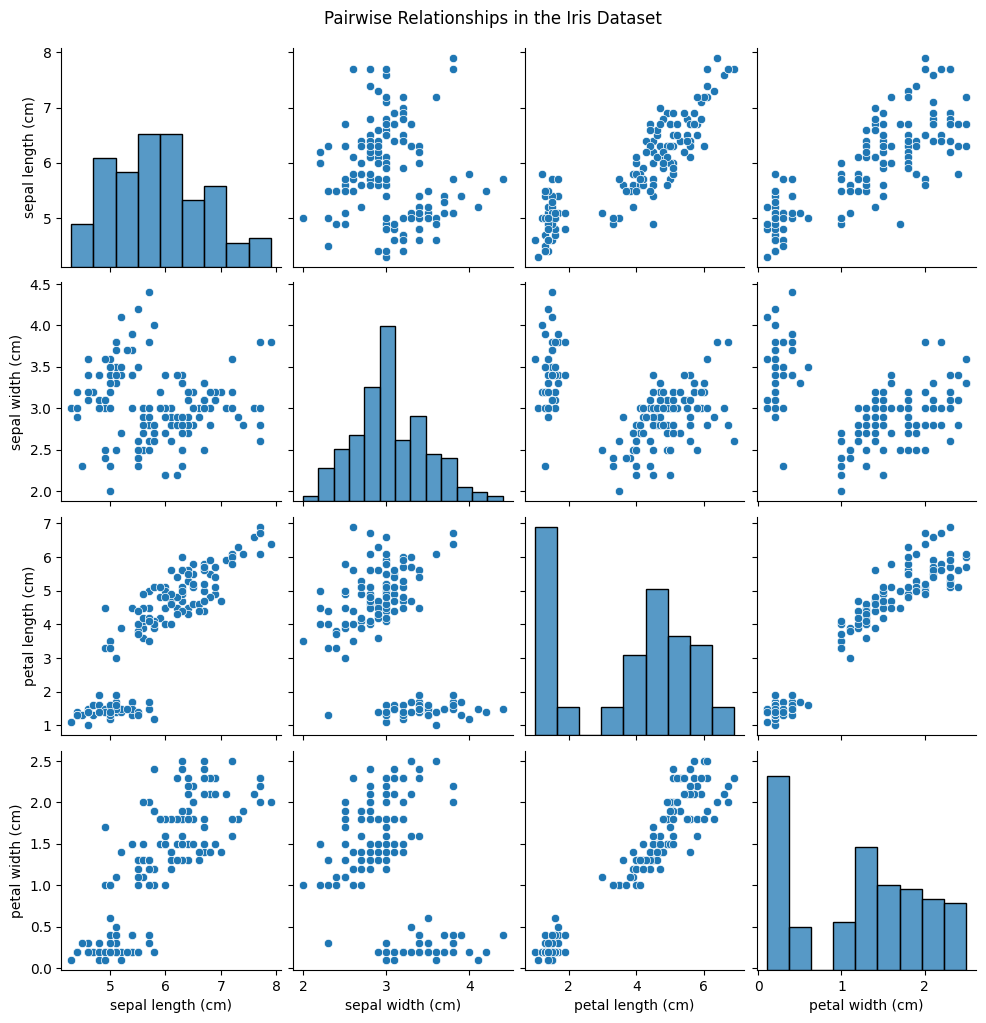

In [5]:
sns.pairplot(X)
plt.suptitle("Pairwise Relationships in the Iris Dataset", y=1.02)
plt.show()

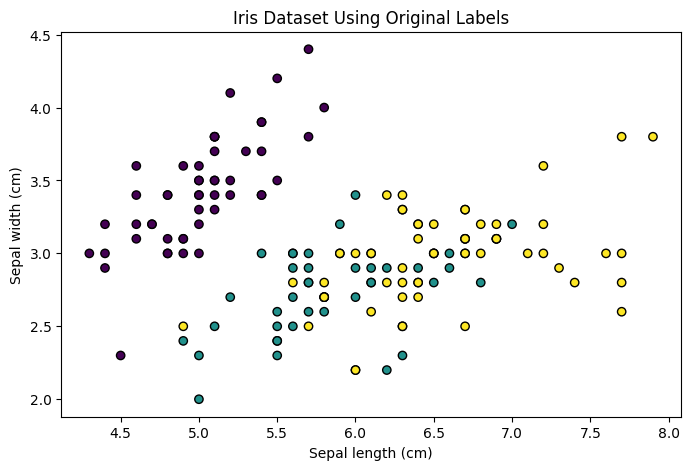

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X["sepal length (cm)"],
    X["sepal width (cm)"],
    c=y,
    cmap="viridis",
    edgecolor="k"
)

plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Iris Dataset Using Original Labels")
plt.show()

Step 5: Standardize the features

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

Step 6: Apply PCA


In [9]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["Principal Component 1", "Principal Component 2"]
)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.72962445 0.22850762]
Total explained variance: 0.9581320720000164


Visualize the PCA representation:



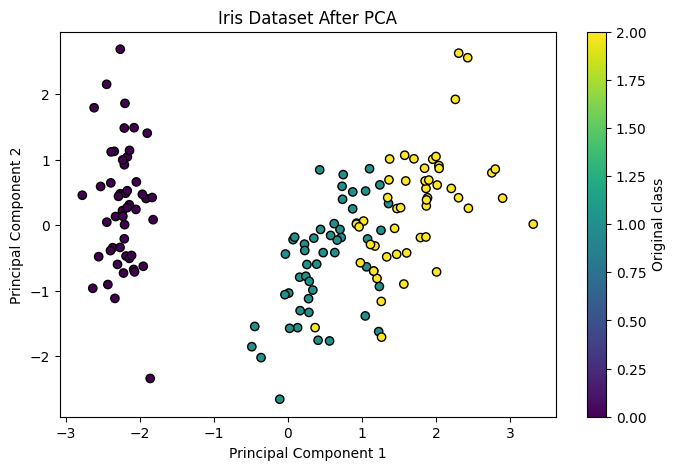

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset After PCA")
plt.colorbar(label="Original class")
plt.show()

Step 7: Select the number of K-Means clusters


In [11]:
inertias = []
silhouette_scores = []

cluster_range = range(2, 8)

for k in cluster_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

Plot the results:



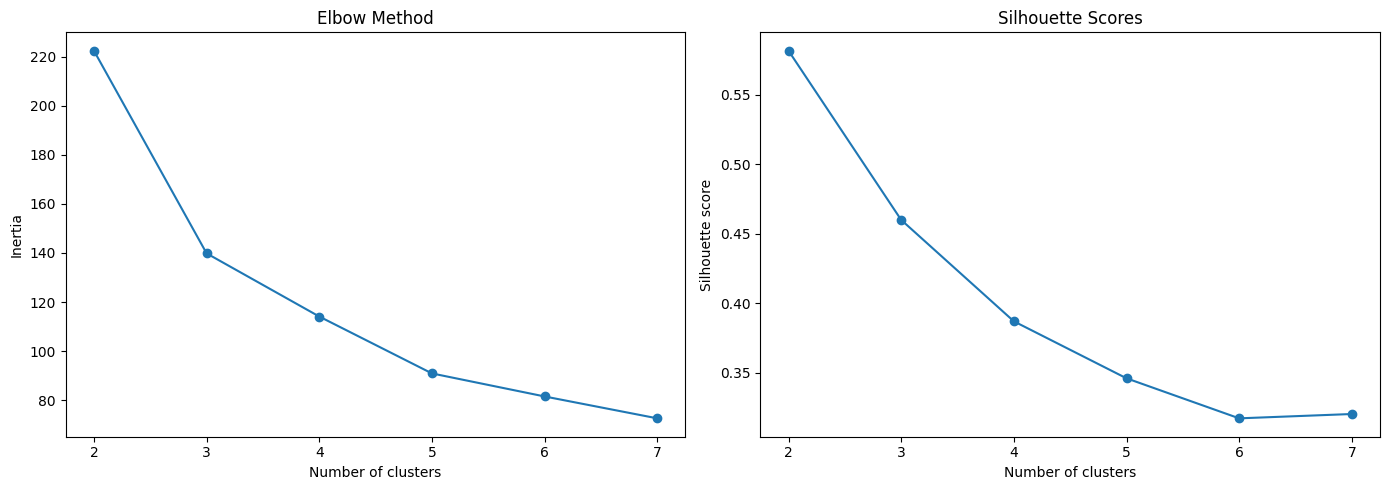

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(cluster_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(cluster_range), silhouette_scores, marker="o")
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

Step 8: Train the K-Means model


In [13]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

X_kmeans = X.copy()
X_kmeans["Cluster"] = kmeans_labels

X_kmeans.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


Visualize K-Means clusters using PCA:



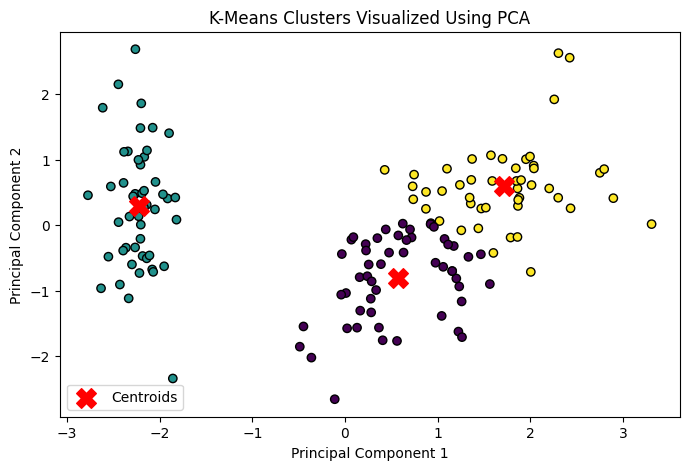

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    edgecolor="k"
)

centers_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized Using PCA")
plt.legend()
plt.show()

Step 9: Apply hierarchical clustering


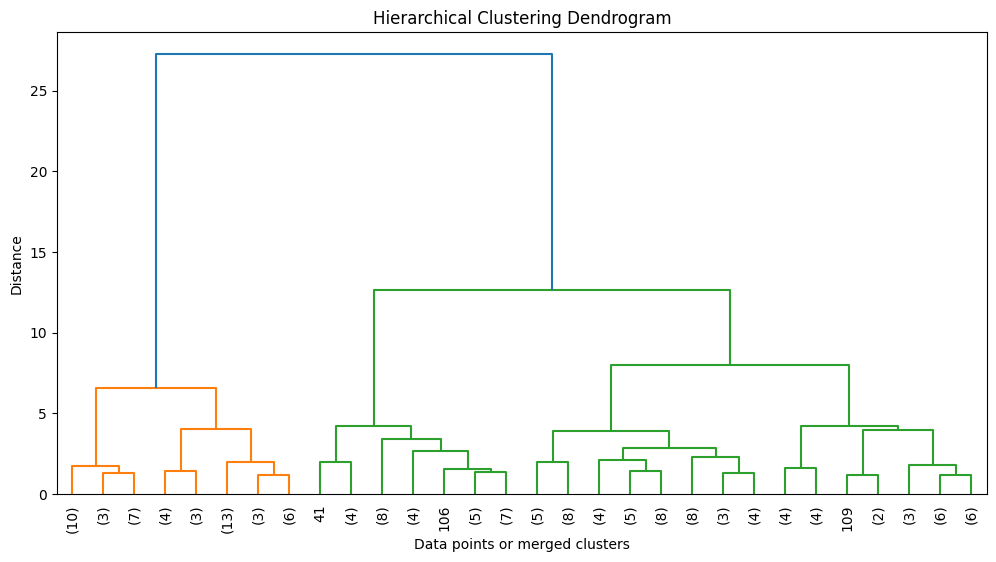

In [15]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data points or merged clusters")
plt.ylabel("Distance")
plt.show()

Now training the hierarchical clustering model:



In [16]:
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

X_hierarchical = X.copy()
X_hierarchical["Cluster"] = hierarchical_labels

Visualize the results:



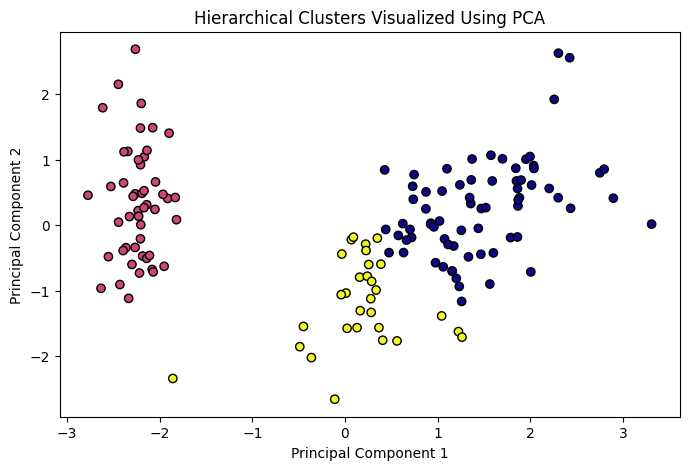

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels,
    cmap="plasma",
    edgecolor="k"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clusters Visualized Using PCA")
plt.show()

Step 10: Evaluate both models


In [18]:
results = pd.DataFrame({
    "Model": ["K-Means", "Hierarchical Clustering"],
    "Silhouette Score": [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, hierarchical_labels)
    ],
    "Davies-Bouldin Index": [
        davies_bouldin_score(X_scaled, kmeans_labels),
        davies_bouldin_score(X_scaled, hierarchical_labels)
    ],
    "Calinski-Harabasz Score": [
        calinski_harabasz_score(X_scaled, kmeans_labels),
        calinski_harabasz_score(X_scaled, hierarchical_labels)
    ]
})

results

,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,0.459948,0.833595,241.904402
1,Hierarchical Clustering,0.446689,0.803467,222.719164


Save the results:



In [19]:
results.to_csv("clustering_evaluation_results.csv", index=False)

Step 11: Compare clusters with known labels


In [20]:
print("K-Means confusion matrix:")
print(confusion_matrix(y, kmeans_labels))

print("\nHierarchical clustering confusion matrix:")
print(confusion_matrix(y, hierarchical_labels))

K-Means confusion matrix:
[[ 0 50  0]
 [39  0 11]
 [14  0 36]]

Hierarchical clustering confusion matrix:
[[ 0 49  1]
 [23  0 27]
 [48  0  2]]


Step 12: Add a model comparison table


In [21]:
comparison = pd.DataFrame({
    "Actual Class": y,
    "K-Means Cluster": kmeans_labels,
    "Hierarchical Cluster": hierarchical_labels
})

comparison.head(10)

,Actual Class,K-Means Cluster,Hierarchical Cluster
0,0,1,1
1,0,1,1
2,0,1,1
3,0,1,1
4,0,1,1
5,0,1,1
6,0,1,1
7,0,1,1
8,0,1,1
9,0,1,1


In [22]:
print("K-Means cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

print("\nHierarchical cluster sizes:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

K-Means cluster sizes:
0    53
1    50
2    47
Name: count, dtype: int64

Hierarchical cluster sizes:
0    71
1    49
2    30
Name: count, dtype: int64
